Importing libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pycountry_convert import country_alpha2_to_continent_code as alpha2_to_continent, convert_continent_code_to_continent_name as continent_name_converter

Loading file

In [2]:
global_data = pd.read_csv('world-data-2023.csv')

Setting no limit to displaying rows and columns 

In [3]:
pd.set_option('display.max_columns', 999)
pd.set_option('display.max_rows', 999)     

Getting basic information about dataset

In [4]:
#getting sample data
global_data.sample(n=5)

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,CPI,CPI Change (%),Currency-Code,Fertility Rate,Forested Area (%),Gasoline Price,GDP,Gross primary education enrollment (%),Gross tertiary education enrollment (%),Infant mortality,Largest city,Life expectancy,Maternal mortality ratio,Minimum wage,Official language,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
5,Antigua and Barbuda,223,AG,20.50%,443,0,15.33,1.0,"St. John's, Saint John",557,113.81,1.20%,XCD,1.99,22.30%,$0.99,"$1,727,759,259",105.00%,24.80%,5.0,"St. John's, Saint John",76.9,42.0,$3.04,English,24.30%,2.76,"97,118",NaN,16.50%,43.00%,NaN,"23,800",17.060816,-61.796428
86,Jordan,115,JO,12.00%,"89,342","116,000",21.98,962.0,Amman,"25,108",125.6,0.80%,JOD,2.76,1.10%,$1.10,"$43,743,661,972",81.50%,34.40%,13.9,Amman,74.4,46.0,$1.49,Arabic,25.10%,2.32,"10,101,694",39.30%,15.10%,28.60%,14.72%,"9,213,048",30.585164,36.238414
148,Samoa,70,WS,12.40%,"2,831",NaN,24.38,685.0,Apia,246,117.56,1.00%,WST,3.88,60.40%,$0.91,"$850,655,017",110.50%,7.60%,13.6,Apia,73.2,43.0,$0.78,Samoan,11.50%,0.34,"202,506",43.70%,25.50%,19.30%,8.36%,"35,588",-13.759029,-172.104629
57,Ethiopia,115,ET,36.30%,"1,104,300","138,000",32.34,251.0,Addis Ababa,"14,870",143.86,15.80%,ETB,4.25,12.50%,$0.75,"$96,107,662,398",101.00%,8.10%,39.1,Addis Ababa,66.2,401.0,NaN,Amharic,37.80%,0.08,"112,078,730",79.60%,7.50%,37.70%,2.08%,"23,788,710",9.145000,40.489673
158,Slovenia,103,SI,30.70%,"20,273","7,000",9.40,386.0,Ljubljana,"12,633",111.05,1.60%,EUR,1.60,62.00%,$1.32,"$53,742,159,517",100.40%,78.60%,1.7,Ljubljana,81.0,7.0,$5.25,Slovene language,12.50%,3.09,"2,087,946",58.40%,18.60%,31.00%,4.20%,"1,144,654",46.151241,14.995463


In [5]:
#getting rows and columns 
rows,columns = global_data.shape
print(f"there are {rows} rows and {columns} columns")

there are 195 rows and 35 columns


In [6]:
#getting basic informations about columns
global_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    195 non-null    object 
 1   Density
(P/Km2)                            195 non-null    object 
 2   Abbreviation                               188 non-null    object 
 3   Agricultural Land( %)                      188 non-null    object 
 4   Land Area(Km2)                             194 non-null    object 
 5   Armed Forces size                          171 non-null    object 
 6   Birth Rate                                 189 non-null    float64
 7   Calling Code                               194 non-null    float64
 8   Capital/Major City                         192 non-null    object 
 9   Co2-Emissions                              188 non-null    object 
 10  CPI                       

In [7]:
# global_data.head()
# global_data.rename(columns={'Co2-Emissions':'Co2-Emissions(in T)','Fertility Rate':'Fertility Rate(per 1000P)','Gasoline Price':'Gasoline Price(in local currency)','Infant mortality':'Infant mortality(per 1000P)','Maternal mortality ratio':'Maternal mortality ratio(per 100,000P)','Minimum wage':'Minimum wage(local currency)','Out of pocket health expenditure':'Out of pocket health expenditure(in %)','Unemployment rate':'Unemployment rate(in %)'})

In [8]:
# Data Type Conversion:
# Columns to convert to float
columns_to_convert = ['Density\n(P/Km2)', 'Agricultural Land( %)', 'Land Area(Km2)',
                      'Birth Rate', 'Co2-Emissions', 'Forested Area (%)',
                      'CPI', 'CPI Change (%)', 'Fertility Rate', 'Gasoline Price', 'GDP',
                      'Gross primary education enrollment (%)', 'Armed Forces size',
                      'Gross tertiary education enrollment (%)', 'Infant mortality',
                      'Life expectancy', 'Maternal mortality ratio', 'Minimum wage', 
                      'Out of pocket health expenditure', 'Physicians per thousand', 
                      'Population', 'Population: Labor force participation (%)', 
                      'Tax revenue (%)', 'Total tax rate', 'Unemployment rate', 'Urban_population']

# Convert columns using a lambda function
global_data[columns_to_convert] = global_data[columns_to_convert].map(lambda x: float(str(x).replace(',', '').replace('$', '').replace('%', '')))

In [9]:
#checking the column types after conversion
global_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    195 non-null    object 
 1   Density
(P/Km2)                            195 non-null    float64
 2   Abbreviation                               188 non-null    object 
 3   Agricultural Land( %)                      188 non-null    float64
 4   Land Area(Km2)                             194 non-null    float64
 5   Armed Forces size                          171 non-null    float64
 6   Birth Rate                                 189 non-null    float64
 7   Calling Code                               194 non-null    float64
 8   Capital/Major City                         192 non-null    object 
 9   Co2-Emissions                              188 non-null    float64
 10  CPI                       

In [10]:
# Changing the names of the columns for more descriptive
global_data.rename(columns={
    global_data.columns[1]: 'Density/n(P/ Km2)',
    'Co2-Emissions': 'Co2-Emissions(in T)',
    'Fertility Rate': 'Fertility Rate(per 1000P)',
    'Gasoline Price': 'Gasoline Price(in local currency)',
    'Infant mortality': 'Infant mortality(per 1000P)',
    'Maternal mortality ratio': 'Maternal mortality ratio(per 100,000P)',
    'Minimum wage': 'Minimum wage(local currency)',
    'Out of pocket health expenditure': 'Out of pocket health expenditure(in %)',
    'Unemployment rate': 'Unemployment rate(in %)'
}, inplace=True)


Preparing data for cleaning and interpolation

In [11]:
#checking how many countries are not having abbreviation
countries_with_null_abbreviation_count = global_data['Abbreviation'].isna().sum()
countries_with_null_abbreviation_count

np.int64(7)

In [12]:
#displaying countries without abbrevation 
countries_with_null_abbreviation = global_data.loc[global_data['Abbreviation'].isna(), ['Country', 'Abbreviation']]
countries_with_null_abbreviation

,Country,Abbreviation
39,Republic of the Congo,NaN
56,Eswatini,NaN
73,Vatican City,NaN
81,Republic of Ireland,NaN
119,Namibia,NaN
128,North Macedonia,NaN
133,Palestinian National Authority,NaN


In [13]:
#adding manually abbrevation 
global_data.loc[global_data['Country'] == 'Republic of the Congo', 'Abbreviation'] = 'CD'
global_data.loc[global_data['Country'] == 'Eswatini', 'Abbreviation'] = 'SZ'
global_data.loc[global_data['Country'] == 'Vatican City', 'Abbreviation'] = 'VA'
global_data.loc[global_data['Country'] == 'Republic of Ireland', 'Abbreviation'] = 'IE'
global_data.loc[global_data['Country'] == 'Namibia', 'Abbreviation'] = 'NA'
global_data.loc[global_data['Country'] == 'North Macedonia', 'Abbreviation'] = 'MK'
global_data.loc[global_data['Country'] == 'Palestinian National Authority', 'Abbreviation'] = 'PS'

In [14]:
global_data.loc[global_data['Abbreviation'] == 'ST', 'Country'] = 'Sao Tome and Principe'

In [15]:
#checking how many countries are not having abbreviation now
countries_with_null_abbreviation_count = global_data['Abbreviation'].isna().sum()
countries_with_null_abbreviation_count

np.int64(0)

Using "pycountry_convert" library for assign continent value for each country 

In [16]:
#function for returning continent based on alpha code 2 of the country
def country_to_continent(country_alpha2):
    try:
        if isinstance(country_alpha2, str) and len(country_alpha2) == 2:
            country_continent_code = alpha2_to_continent(country_alpha2)
            country_continent_name = continent_name_converter(country_continent_code)
            return country_continent_name
        else:
            return None  
    except KeyError:
        return None 

In [17]:
#Creating new column on desired position and filling with 'None' values
global_data.insert(0, 'Continent', None)

In [18]:
#Filling up the rows in Continent with using function country_to_continent
global_data['Continent'] = global_data['Abbreviation'].map(lambda x: country_to_continent(x))

In [19]:
#checking if all of the countries are having continent value 
countries_with_null_continent_count = global_data['Continent'].isna().sum()
countries_with_null_continent_count

np.int64(2)

In [20]:
#displaying countries with missing values
countries_with_null_continent = global_data.loc[global_data['Continent'].isna(),['Country','Continent']]
countries_with_null_continent

,Country,Continent
73,Vatican City,None
174,East Timor,None


In [21]:
#manual assigning values countries
global_data.loc[global_data['Country'] == 'Vatican City', 'Continent'] = 'Europe'
global_data.loc[global_data['Country'] == 'East Timor', 'Continent'] = 'Asia'

In [22]:
#rechecking if all of the countries are having sucesfully continent value 
countries_with_null_continent_count = global_data['Continent'].isna().sum()
countries_with_null_continent_count

np.int64(0)

Data interpolation based on continent

In [23]:
#displaying the count of missing values for each column
missing_values_count= global_data.isna().sum()
missing_values_count

Continent                                     0
Country                                       0
Density/n(P/ Km2)                             0
Abbreviation                                  0
Agricultural Land( %)                         7
Land Area(Km2)                                1
Armed Forces size                            24
Birth Rate                                    6
Calling Code                                  1
Capital/Major City                            3
Co2-Emissions(in T)                           7
CPI                                          17
CPI Change (%)                               16
Currency-Code                                15
Fertility Rate(per 1000P)                     7
Forested Area (%)                             7
Gasoline Price(in local currency)            20
GDP                                           2
Gross primary education enrollment (%)        7
Gross tertiary education enrollment (%)      12
Infant mortality(per 1000P)             

In [24]:
missing_values_by_country = global_data.groupby('Country').apply(lambda x: x.isna().sum().sum())
countries_with_missing_values = missing_values_by_country[missing_values_by_country >= 4]
print(countries_with_missing_values.count())

24


C:\Users\filip\AppData\Local\Temp\ipykernel_10028\1987907769.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_values_by_country = global_data.groupby('Country').apply(lambda x: x.isna().sum().sum())


In [25]:
#removing the countries which are having 4 or more 'Nan' values, cause in fact after interpolation we would be having countries representing means of each column 
#,but most of this countries are having extreme values so representing the =m by mean is incorrect
countries_with_missing_values_index = countries_with_missing_values.index
global_data = global_data[~global_data['Country'].isin(countries_with_missing_values_index)]

In [26]:
missing_values_by_country = global_data.groupby('Country').apply(lambda x: x.isna().sum().sum())
countries_with_missing_values = missing_values_by_country[missing_values_by_country >= 4]
print(countries_with_missing_values.count())

0


C:\Users\filip\AppData\Local\Temp\ipykernel_10028\1987907769.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_values_by_country = global_data.groupby('Country').apply(lambda x: x.isna().sum().sum())


In [27]:
#printing missing values grouped by contients  
def percent_of_missing_values(column_by_continent):
    return (column_by_continent.isna().sum() / len(column_by_continent)) * 100
missing_values_by_continent = global_data.groupby('Continent').apply(lambda x: x.apply(percent_of_missing_values))
#print(missing_values_by_continent)

C:\Users\filip\AppData\Local\Temp\ipykernel_10028\1920386860.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_values_by_continent = global_data.groupby('Continent').apply(lambda x: x.apply(percent_of_missing_values))


In [28]:
#theese countries were appealing to the most of missing values, currently we can do the interpolation 
missing_values_by_continent = global_data.groupby('Continent').apply(lambda x: x.apply(percent_of_missing_values))
#print(missing_values_by_continent)

C:\Users\filip\AppData\Local\Temp\ipykernel_10028\1694841499.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_values_by_continent = global_data.groupby('Continent').apply(lambda x: x.apply(percent_of_missing_values))


In [29]:
#Value interpolation of ... based on the mean from the same continent
def fill_missing_values_groupby_continent_mean(df,*column_names):
    for column_name in column_names:
        continent_means = df.groupby('Continent')[column_name].transform('mean').round(2)
        #df[column_name].fillna(continent_means, inplace=True) will be not supported in future versions
        df.fillna({column_name: continent_means}, inplace=True)


In [30]:
#creating the list of columns which missing values will be interpolated by continent mean
list = [
    "Density/n(P/ Km2)", "Agricultural Land( %)", "Land Area(Km2)", "Birth Rate", 
    "Co2-Emissions(in T)", "CPI", "CPI Change (%)", "Fertility Rate(per 1000P)", "Forested Area (%)", 
    "Gasoline Price(in local currency)", "GDP", "Gross primary education enrollment (%)", 
    "Gross tertiary education enrollment (%)", "Infant mortality(per 1000P)", "Life expectancy", 
    "Maternal mortality ratio(per 100,000P)", "Minimum wage(local currency)", 
    "Out of pocket health expenditure(in %)", "Physicians per thousand", "Population", 
    "Population: Labor force participation (%)", "Tax revenue (%)", "Total tax rate", 
    "Unemployment rate(in %)", "Urban_population"
]


In [31]:
#rechecking the values
missing_values_by_continent = global_data.groupby('Continent').apply(lambda x: x.apply(percent_of_missing_values))
print(missing_values_by_continent)

               Continent  Country  Density/n(P/ Km2)  Abbreviation  \
Continent                                                            
Africa               0.0      0.0                0.0           0.0   
Asia                 0.0      0.0                0.0           0.0   
Europe               0.0      0.0                0.0           0.0   
North America        0.0      0.0                0.0           0.0   
Oceania              0.0      0.0                0.0           0.0   
South America        0.0      0.0                0.0           0.0   

               Agricultural Land( %)  Land Area(Km2)  Armed Forces size  \
Continent                                                                 
Africa                           0.0             0.0           2.040816   
Asia                             0.0             0.0           0.000000   
Europe                           0.0             0.0           0.000000   
North America                    0.0             0.0          10

C:\Users\filip\AppData\Local\Temp\ipykernel_10028\2021649411.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_values_by_continent = global_data.groupby('Continent').apply(lambda x: x.apply(percent_of_missing_values))


In [32]:
#calling with the list as argument 
fill_missing_values_groupby_continent_mean(global_data,*list)

In [33]:
missing_values = global_data.isna().sum()
missing_values = missing_values[missing_values>0]
missing_values

Armed Forces size      7
Capital/Major City     2
Currency-Code         13
Largest city           3
Official language      4
dtype: int64

In [34]:
#from the persepctive of our project language, currency, largest city, or official columns, are not important so for now we are going to get rid off them. 
global_data = global_data.drop(columns=missing_values.index)  

In [35]:
#rechecking if we finally are lack of 'Nan' values:
missing_values = global_data.isna().sum()
missing_values = missing_values[missing_values>0]
missing_values

Series([], dtype: int64)

Adding columns

In [36]:
# df["Urban Population percentage"] = df["Urban_population"] / df["Population"]
# df["GDP rank"] = df["GDP"].rank(ascending=False)
# df["Continent GDP"] = df.groupby("Continent")["GDP"].transform("sum")
# df["Contribution to the Continent GDP"] = (df["GDP"] / df["Continent GDP"]).round(2)
# df["GDP per Population"] = df["GDP"] / df["Population"]
# df["Co2-Emissions per Population"] = df["Co2-Emissions"] / df["Population"]
# df["Post Tax Minimum wage"] = df["Minimum wage"] * (1 - df["Total tax rate"])
# df["GDP_per_capita"]=df["GDP"]/df["Population"]

Data visualisation

In [37]:
#Creating a function to compare desired attribute for all countries:
def attribute_by_country_globally(df,column='Population',numbers=10,sorting=False):
    att_by_country_globally = df[['Country', column]]
    att_by_country_globally = att_by_country_globally.sort_values(by=column,ascending=sorting)
    att_by_country_globally = att_by_country_globally.head(numbers)
    plt.figure(figsize=(20,10))
    sns.barplot(x='Country', y=column, data=att_by_country_globally)    
    if sorting==True:
        top = "smallest"
    else:
        top = "biggest"

    plt.title(f'Top {numbers} countries with the {top} {column} globally')
    plt.ylabel(f'{column}')
    plt.xlabel(f'Countries')
    plt.show()

In [38]:
#Creating a function to compare desired value for all continents
def attribute_by_continent(df,column='Population',sorting=False):
    att_by_continent = global_data.groupby('Continent')[column].sum()
    att_by_continent = att_by_continent.sort_values(ascending=sorting)
    plt.figure(figsize=(20,10))
    sns.barplot(x=att_by_continent.index, y=att_by_continent.values)
    if sorting==True:
        top = "ascendingly"
    else:
        top = "descendingly"
    plt.title(f'Continents by {column} {top}')
    plt.ylabel(f'{column}')
    plt.xlabel('Continent name')
    plt.show()

In [39]:
def attribute_by_country_in_continent(df,continent,column='Population',numbers=10, sorting=False):
    att_by_country_in_continent = df[df['Continent'] == continent].groupby('Country')[column].sum()
    att_by_country_in_continent = att_by_country_in_continent.sort_values(ascending=sorting)
    att_by_country_in_continent = att_by_country_in_continent.head(numbers)
    plt.figure(figsize=(20,10))
    sns.barplot(x=att_by_country_in_continent.index, y=att_by_country_in_continent.values)
    if sorting==True:
        top = "smallest"
    else:
        top = "biggest"

    plt.title(f'Top {numbers} countries with the {top} {column} in {continent}')
    plt.ylabel(f'{column}')
    plt.xlabel(f'Countries of {continent}')
    plt.show()


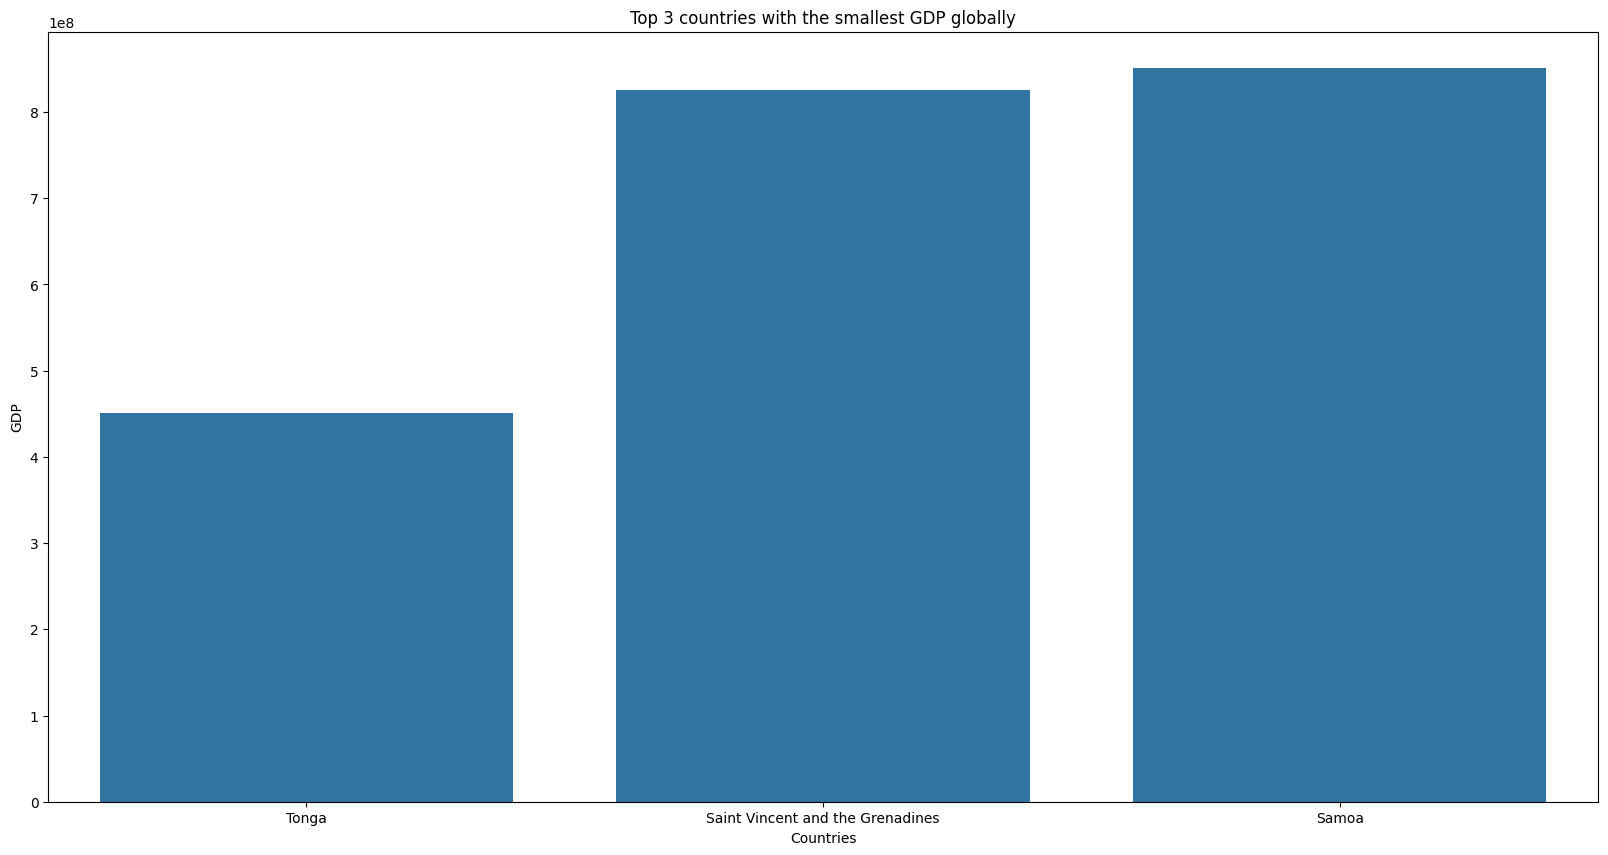

In [40]:
attribute_by_country_globally(global_data, column='GDP',numbers=3,sorting=True)

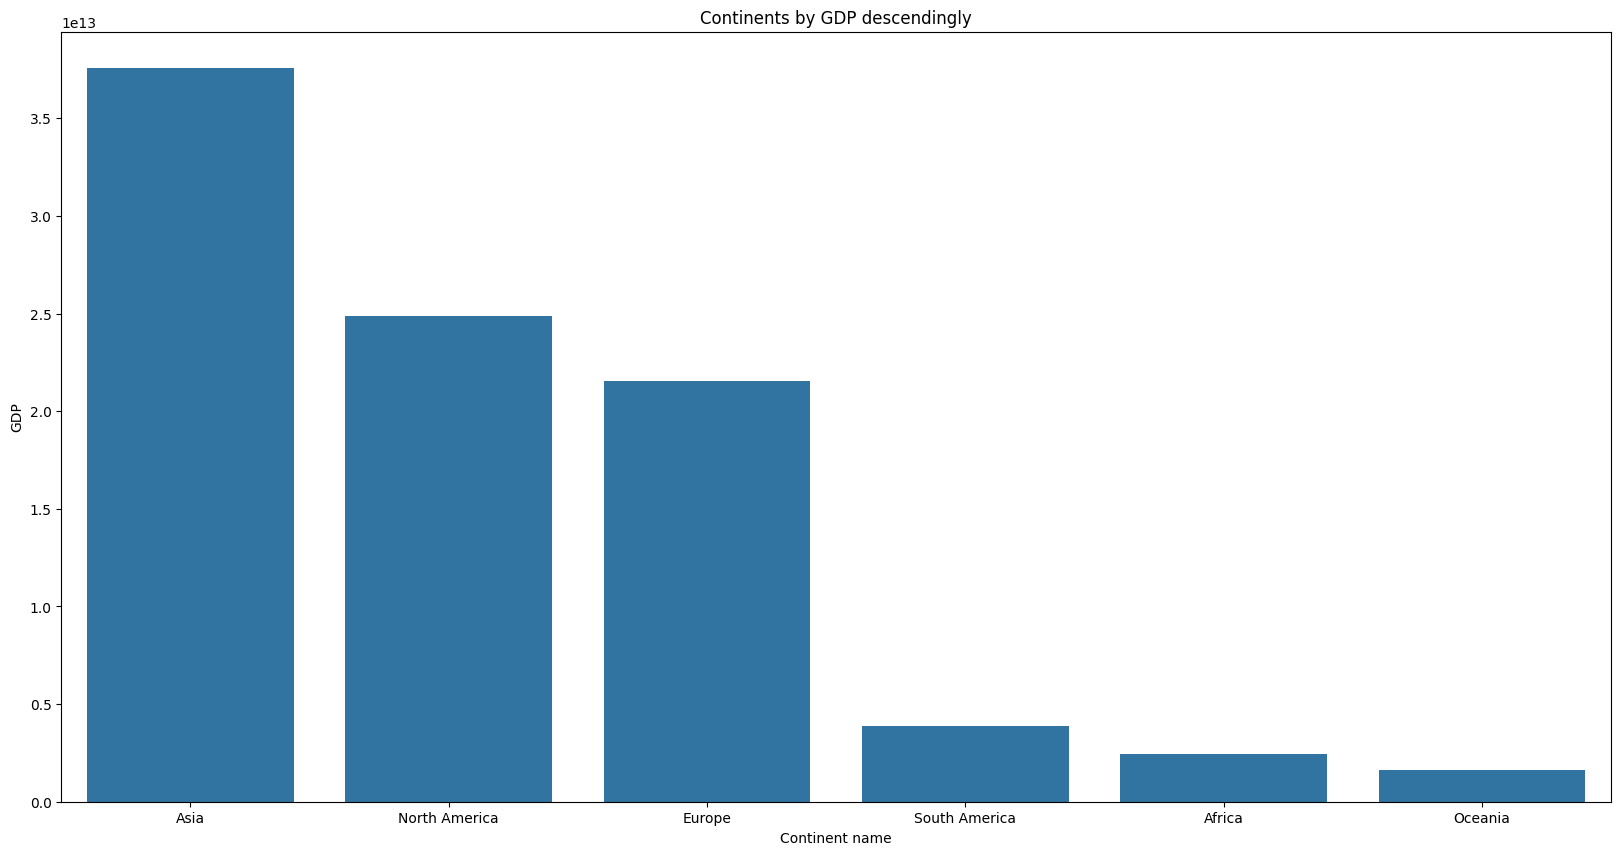

In [41]:
attribute_by_continent(global_data,column='GDP')

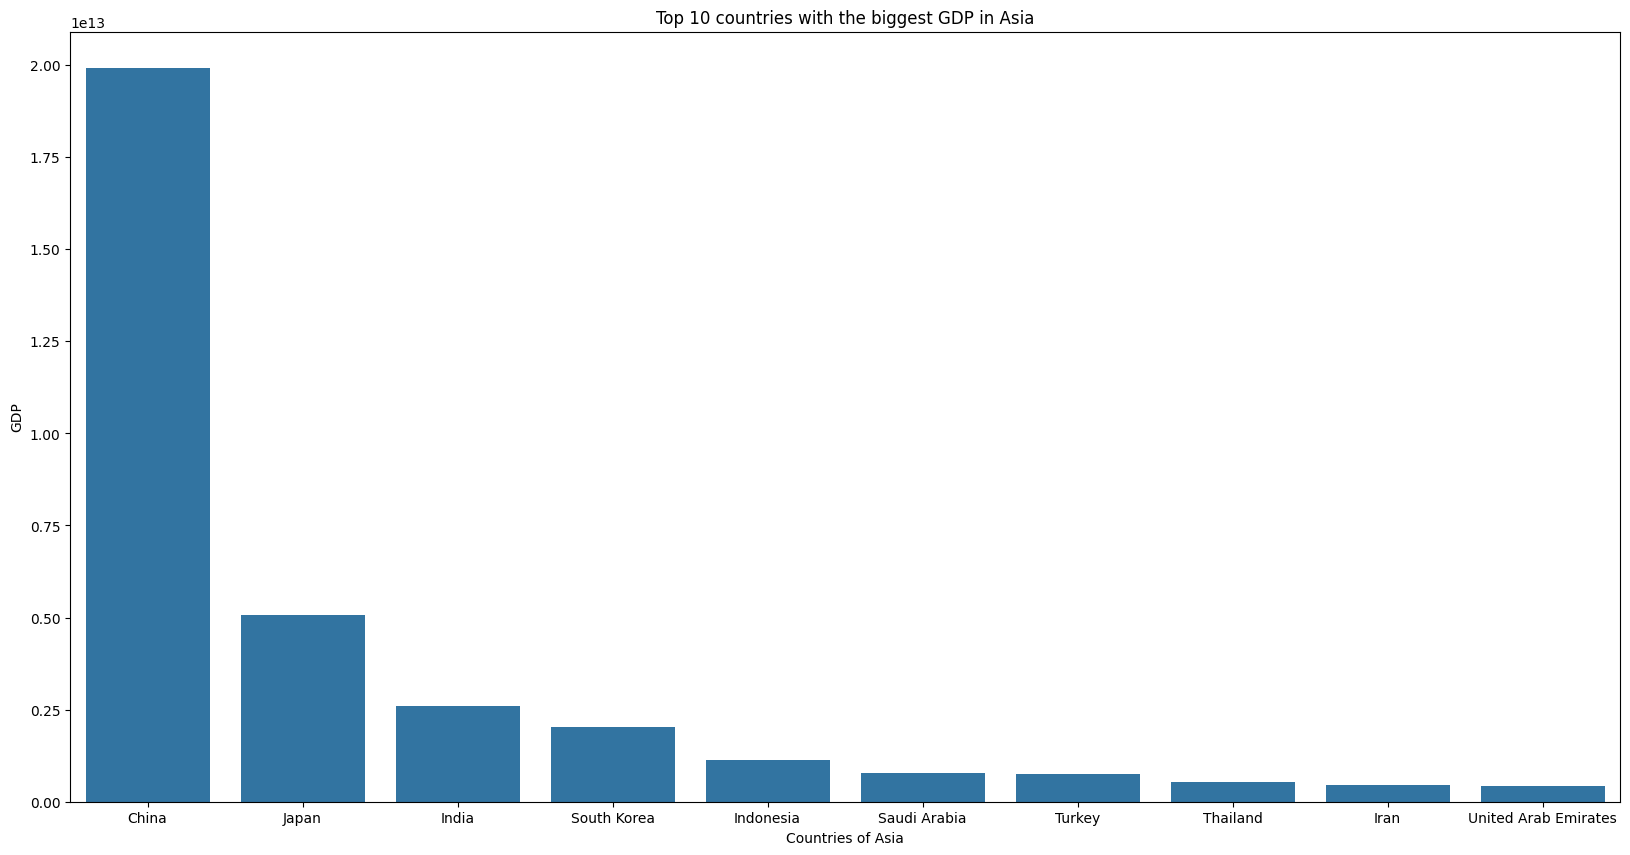

In [42]:
#displaying top10 countries by population in Asia
attribute_by_country_in_continent(global_data,'Asia',column='GDP')


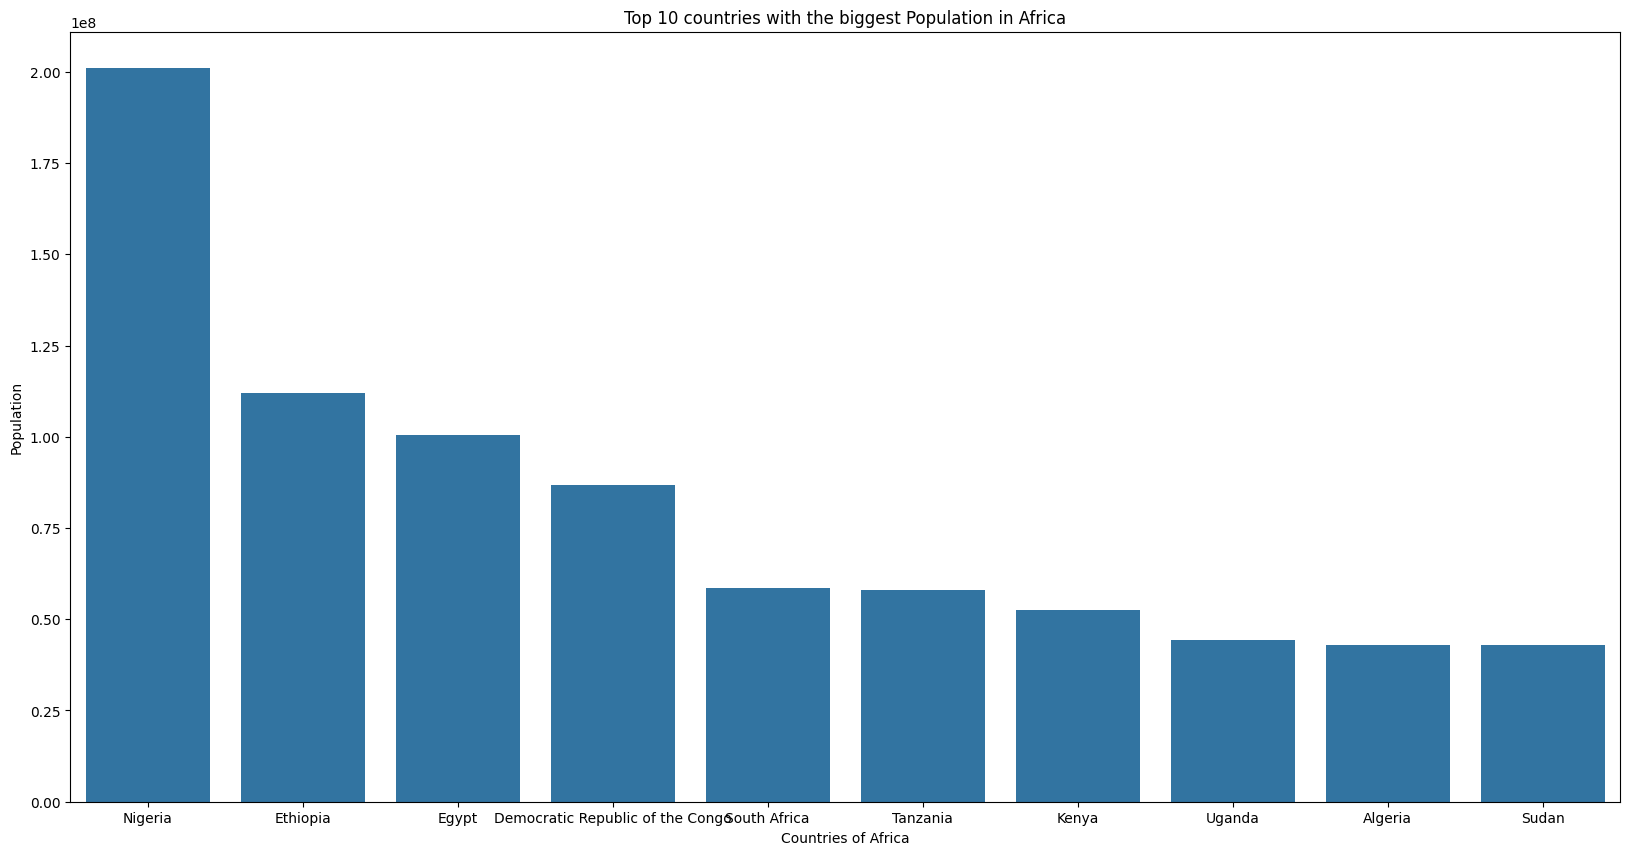

In [43]:
#Displaying least populated countries in Asia
attribute_by_country_in_continent(global_data,'Africa',sorting=False)

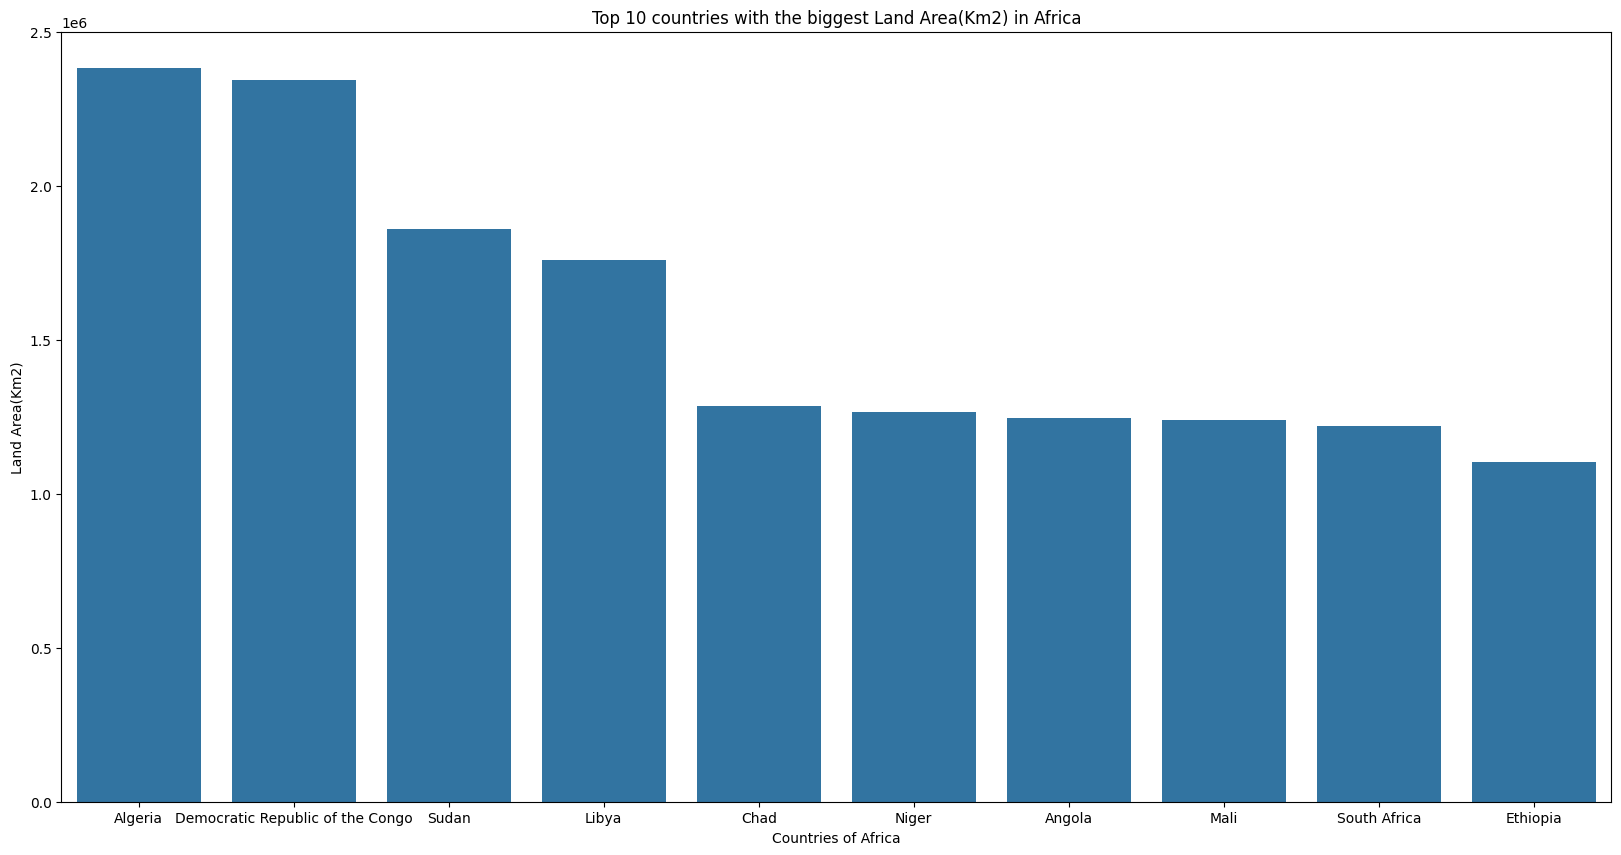

In [44]:
#Displaying least populated countries in Asia
attribute_by_country_in_continent(global_data,'Africa',column='Land Area(Km2)',sorting=False)

Checking the correlation between float columns with using heatmap

In [45]:
#Choosing the float columns 
numeric_data = global_data[[
    'Density/n(P/ Km2)', 'Agricultural Land( %)', 'Land Area(Km2)',
    'Birth Rate', 'Co2-Emissions(in T)', 'Forested Area (%)',
    'CPI', 'CPI Change (%)', 'Fertility Rate(per 1000P)', 'Gasoline Price(in local currency)', 
    'GDP', 'Gross primary education enrollment (%)',
    'Gross tertiary education enrollment (%)', 'Infant mortality(per 1000P)',
    'Life expectancy', 'Maternal mortality ratio(per 100,000P)', 'Minimum wage(local currency)',
    'Out of pocket health expenditure(in %)', 'Physicians per thousand',
    'Population', 'Population: Labor force participation (%)', 
    'Tax revenue (%)', 'Total tax rate', 'Unemployment rate(in %)', 'Urban_population'
]]

correlation_matrix = numeric_data.corr()

<Axes: >

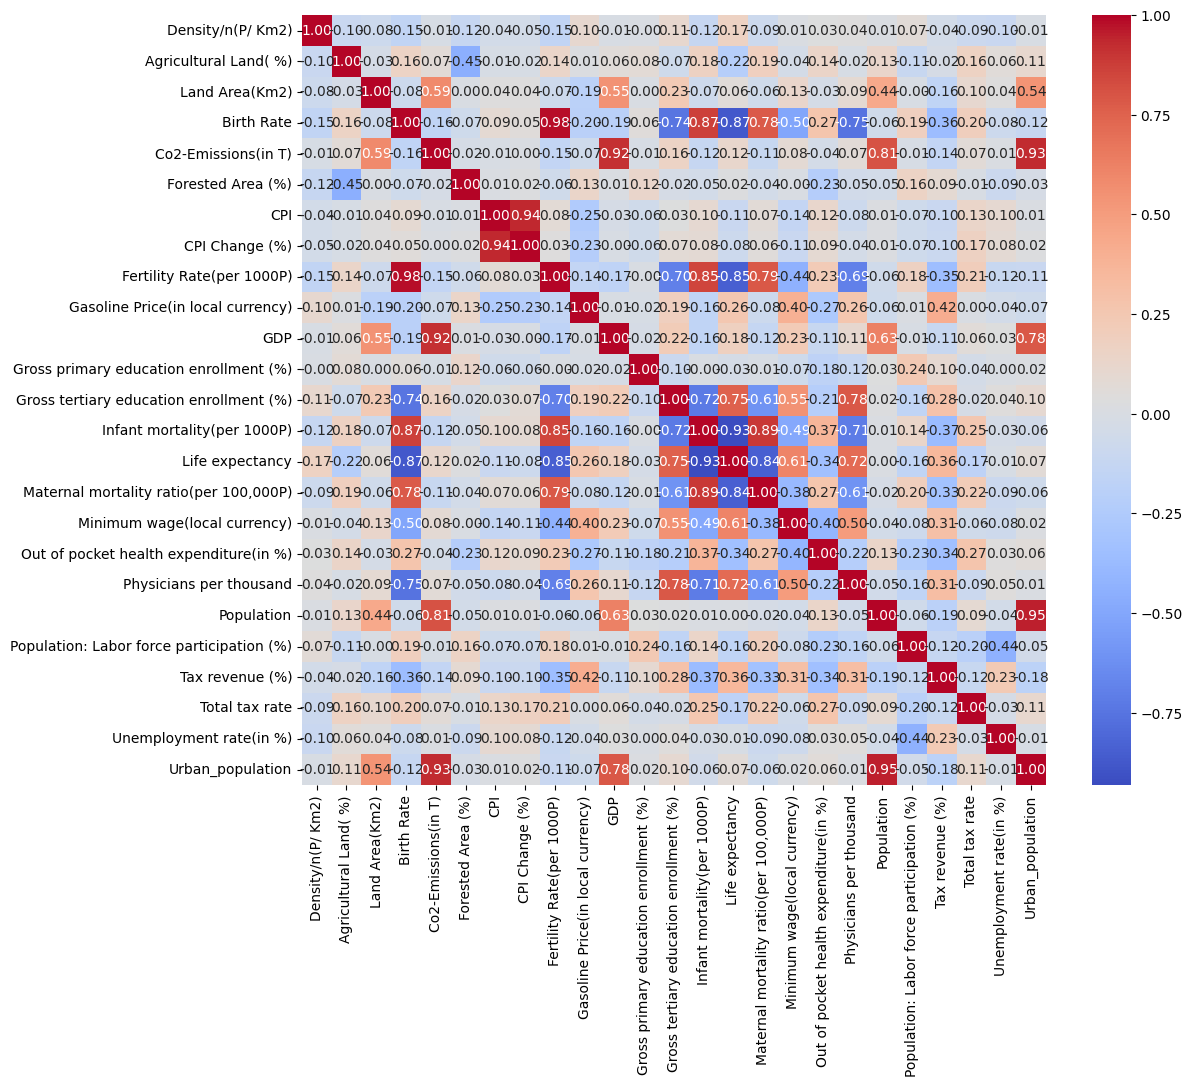

In [46]:
#using heatmap to check the correlation between attributes
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

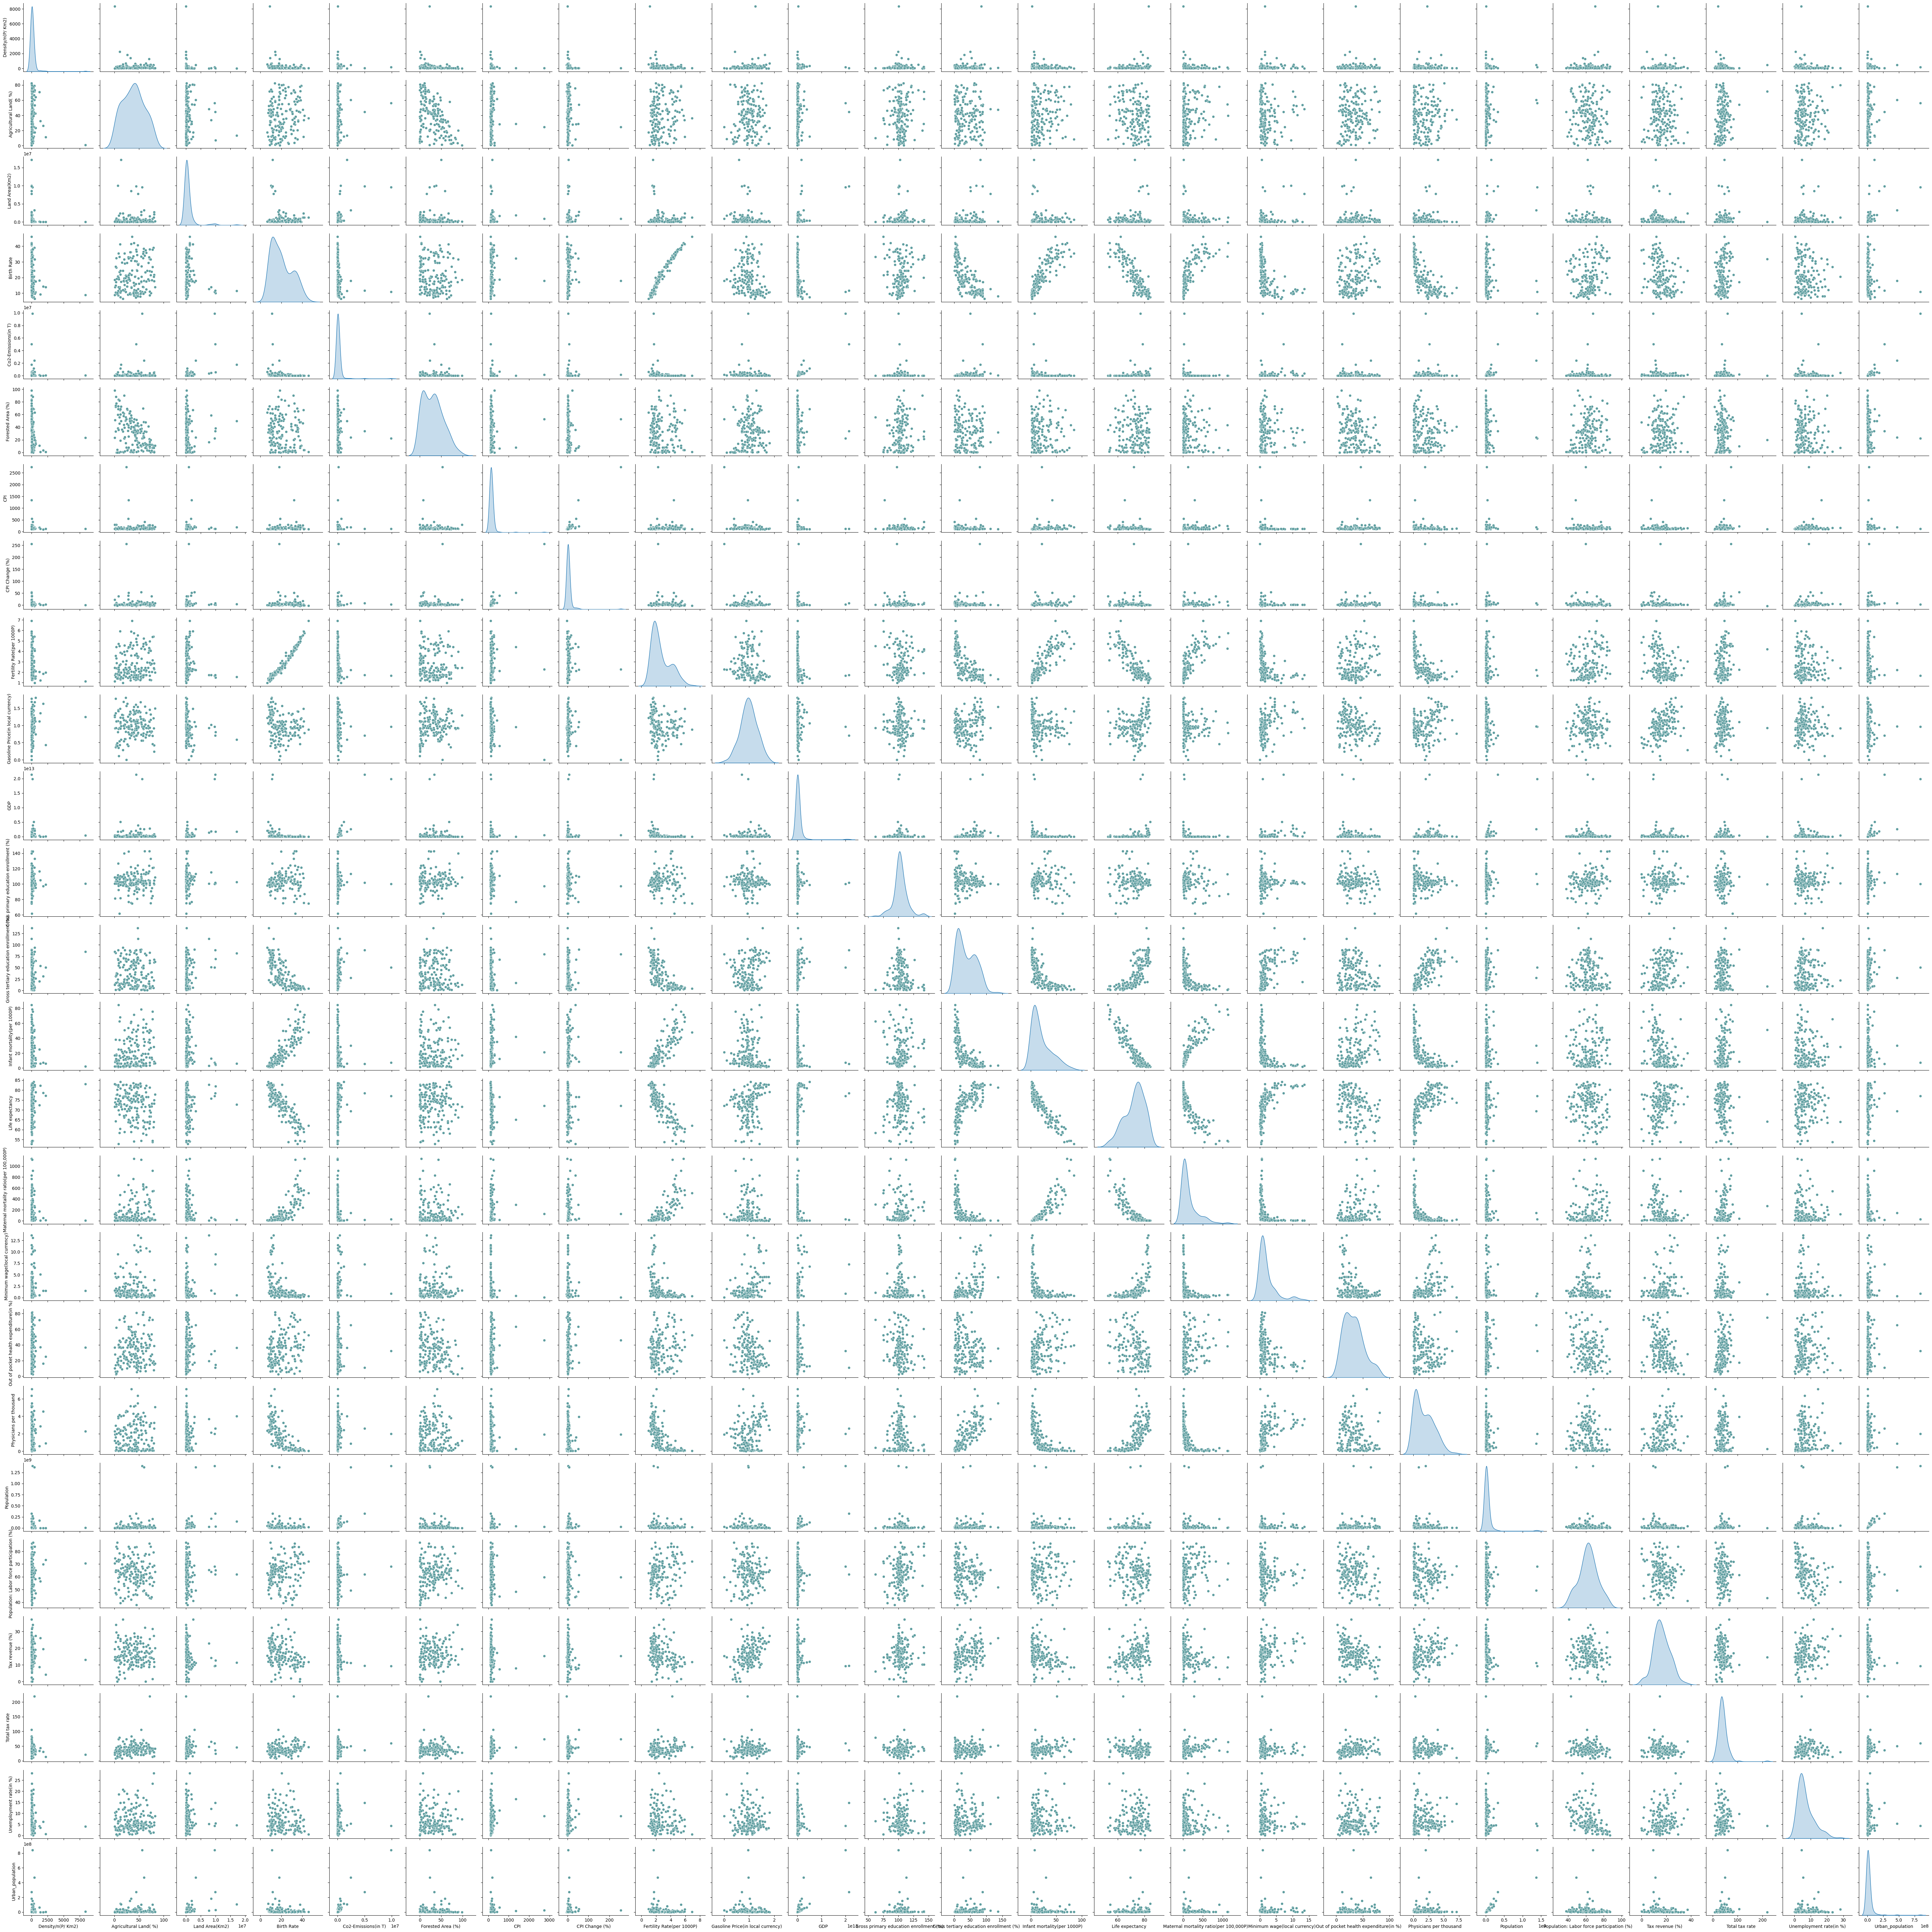

<Axes: xlabel='Urban_population', ylabel='Co2-Emissions(in T)'>

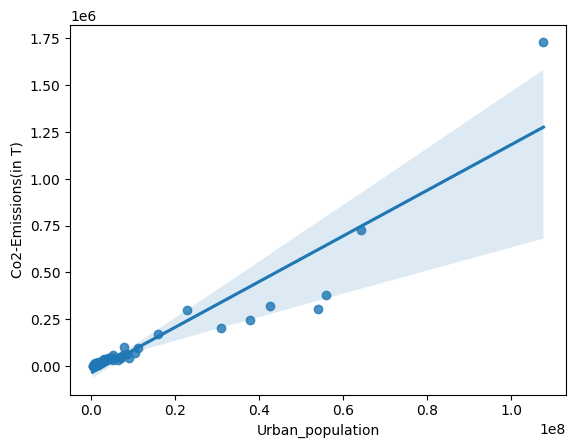

In [48]:
europe_data = global_data[global_data['Continent'] == 'Europe']
sns.regplot(x=europe_data['Urban_population'], y=europe_data['Co2-Emissions(in T)'])

<Axes: xlabel='Urban_population', ylabel='Co2-Emissions(in T)'>

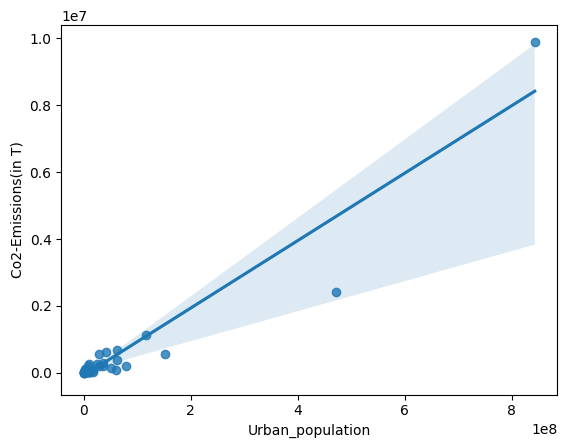

In [49]:
asia_data = global_data[global_data['Continent'] == 'Asia']
sns.regplot(x=asia_data['Urban_population'], y=asia_data['Co2-Emissions(in T)'])

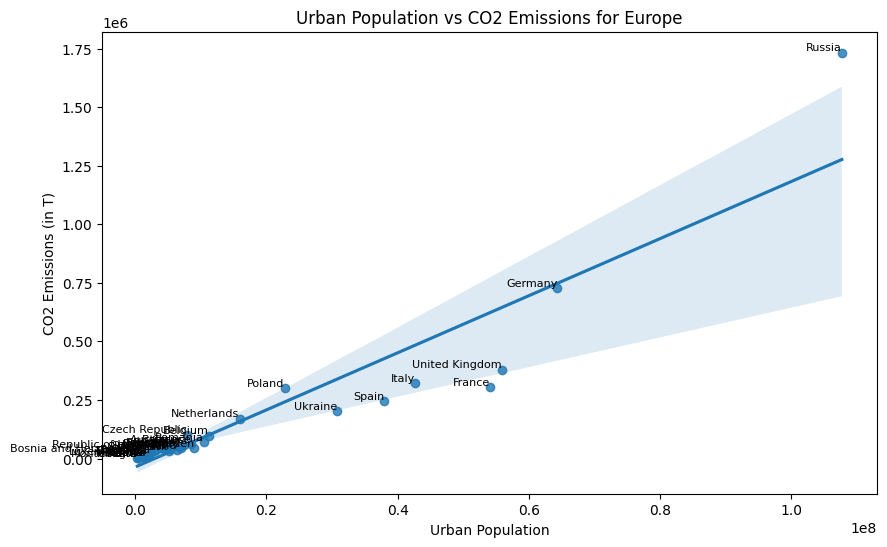

In [50]:
# Filtracja danych dla Europy
europe_data = global_data[global_data['Continent'] == 'Europe']

# Tworzenie wykresu regresji
plt.figure(figsize=(10, 6))
ax = sns.regplot(x=europe_data['Urban_population'], y=europe_data['Co2-Emissions(in T)'])

# Dodanie etykiet (krajów) do punktów na wykresie
for i in range(len(europe_data)):
    ax.text(europe_data['Urban_population'].iloc[i], 
            europe_data['Co2-Emissions(in T)'].iloc[i], 
            europe_data['Country'].iloc[i], 
            fontsize=8, 
            ha='right', 
            va='bottom', 
            color='black')

# Dodatkowe ustawienia wykresu
plt.title('Urban Population vs CO2 Emissions for Europe')
plt.xlabel('Urban Population')
plt.ylabel('CO2 Emissions (in T)')

plt.show()

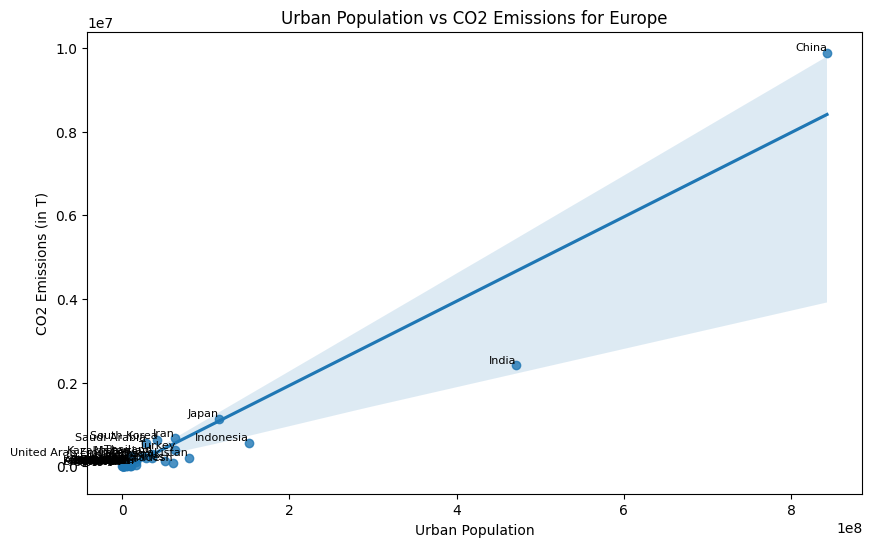

In [51]:
# Filtracja danych dla Europy
asia_data = global_data[global_data['Continent'] == 'Asia']

# Tworzenie wykresu regresji
plt.figure(figsize=(10, 6))
ax = sns.regplot(x=asia_data['Urban_population'], y=asia_data['Co2-Emissions(in T)'])

# Dodanie etykiet (krajów) do punktów na wykresie
for i in range(len(asia_data)):
    ax.text(asia_data['Urban_population'].iloc[i], 
            asia_data['Co2-Emissions(in T)'].iloc[i], 
            asia_data['Country'].iloc[i], 
            fontsize=8, 
            ha='right', 
            va='bottom', 
            color='black')

# Dodatkowe ustawienia wykresu
plt.title('Urban Population vs CO2 Emissions for Europe')
plt.xlabel('Urban Population')
plt.ylabel('CO2 Emissions (in T)')

plt.show()